## ECG black-hat after derivative decomposition

This notebook tests the decomposition you described.

We write the synthetic image as:

`synthetic = derivative_component + residual_component`

Then we:
1. apply black-hat only to the residual part,
2. add the derivative part back,
3. compare the final image with black-hat only.

### Choice made here
I use a **Sobel magnitude** component for the derivative part.
It is non-negative and easier to combine in image space.

### Goal
We want to know if preserving a derivative-like detail component helps more than black-hat only.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------
# Configuration
# ---------------------------------
base_path = Path("../../data/sample")
selected_ecg_id = "11842146"
clean_scan = "0001"

# Synthetic ink
RANDOM_SEED = 19
N_STROKES = 15
N_BLOBS = 8
N_SMUDGES = 5

# Derivative decomposition
DERIVATIVE_WEIGHT = 0.20

# Black-hat
CLOSING_KERNEL = 25


## Helper functions

These functions keep the main steps short.


In [2]:
def load_gray_image(ecg_id, scan_type):
    path = base_path / ecg_id / f"{ecg_id}-{scan_type}.png"
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {path}")
    return img.astype(np.float32) / 255.0, path


def to_u8(img):
    return np.clip(np.round(img * 255.0), 0, 255).astype(np.uint8)


def masked_mae(a, b, mask):
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[mask] - b[mask])))


def normalize_for_display(img):
    img = img.astype(np.float32)
    lo = float(img.min())
    hi = float(img.max())
    if hi - lo < 1e-8:
        return np.zeros_like(img)
    return (img - lo) / (hi - lo)


def odd_kernel_size(k):
    k = int(k)
    if k < 3:
        k = 3
    if k % 2 == 0:
        k += 1
    return k


def generate_random_ink_from_clean(clean_img, seed=7, n_strokes=14, n_blobs=10, n_smudges=4):
    rng = np.random.default_rng(seed)
    h, w = clean_img.shape

    stroke_layer = np.zeros((h, w), dtype=np.float32)
    blob_layer = np.zeros((h, w), dtype=np.float32)
    smudge_layer = np.zeros((h, w), dtype=np.float32)

    # Dark thin strokes.
    for _ in range(n_strokes):
        x1 = int(rng.integers(0, w))
        y1 = int(rng.integers(0, h))
        length = int(rng.integers(min(h, w) // 30, min(h, w) // 8))
        angle = float(rng.uniform(0, 2 * np.pi))
        x2 = int(np.clip(x1 + length * np.cos(angle), 0, w - 1))
        y2 = int(np.clip(y1 + length * np.sin(angle), 0, h - 1))
        thickness = int(rng.integers(2, 8))
        value = float(rng.uniform(0.18, 0.45))
        cv2.line(stroke_layer, (x1, y1), (x2, y2), value, thickness, lineType=cv2.LINE_AA)

    # Compact blobs.
    for _ in range(n_blobs):
        center = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        axes = (
            int(rng.integers(max(4, w // 80), max(8, w // 25))),
            int(rng.integers(max(4, h // 80), max(8, h // 25))),
        )
        angle = float(rng.uniform(0, 180))
        value = float(rng.uniform(0.10, 0.60))
        cv2.ellipse(blob_layer, center, axes, angle, 0, 360, value, -1, lineType=cv2.LINE_AA)

    # Broad faint smudges.
    for _ in range(n_smudges):
        center = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        axes = (
            int(rng.integers(max(20, w // 25), max(40, w // 10))),
            int(rng.integers(max(20, h // 25), max(40, h // 10))),
        )
        angle = float(rng.uniform(0, 180))
        value = float(rng.uniform(0.03, 0.50))
        cv2.ellipse(smudge_layer, center, axes, angle, 0, 360, value, -1, lineType=cv2.LINE_AA)

    blob_layer = cv2.GaussianBlur(blob_layer, (0, 0), sigmaX=3, sigmaY=3)
    smudge_layer = cv2.GaussianBlur(smudge_layer, (0, 0), sigmaX=11, sigmaY=11)

    darkening = np.clip(stroke_layer + blob_layer + smudge_layer, 0.0, 0.99)
    synthetic_ink = np.clip(clean_img - darkening, 0.0, 1.0)
    true_ink_mask = darkening > 0.03
    return synthetic_ink, darkening, true_ink_mask


def build_blackhat_only(img, closing_kernel):
    img_u8 = to_u8(img)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (closing_kernel, closing_kernel))
    background_u8 = cv2.morphologyEx(img_u8, cv2.MORPH_CLOSE, kernel)
    blackhat_u8 = cv2.subtract(background_u8, img_u8)
    blackhat_only = 1.0 - (blackhat_u8.astype(np.float32) / 255.0)
    return blackhat_only, background_u8.astype(np.float32) / 255.0, blackhat_u8.astype(np.float32) / 255.0


def build_sobel_derivative_component(img, weight):
    sobel_x = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
    sobel_mag = np.sqrt(sobel_x ** 2 + sobel_y ** 2)
    sobel_norm = normalize_for_display(sobel_mag)

    # Keep the derivative component small and non-negative.
    derivative_component = np.minimum(img, weight * sobel_norm)
    residual_component = img - derivative_component
    return derivative_component, residual_component, sobel_mag


def collect_metrics(name, img, clean_img, true_ink_mask):
    full_mask = np.ones_like(clean_img, dtype=bool)
    return {
        "method": name,
        "all": masked_mae(img, clean_img, full_mask),
        "ink": masked_mae(img, clean_img, true_ink_mask),
        "outside": masked_mae(img, clean_img, ~true_ink_mask),
    }


def draw_results_table(rows):
    headers = ["Method", "MAE all", "MAE ink mask", "MAE outside mask"]
    cell_text = []
    for row in rows:
        cell_text.append([
            row["method"],
            f"{row['all']:.6f}",
            f"{row['ink']:.6f}",
            f"{row['outside']:.6f}",
        ])

    fig, ax = plt.subplots(figsize=(10, 2.2 + 0.55 * len(rows)))
    ax.axis("off")
    table = ax.table(cellText=cell_text, colLabels=headers, loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.7)
    plt.tight_layout()
    plt.show()


## Step 1 - Load the clean image

This is the exact target.


ECG ID: 11842146
Clean path: ..\..\data\sample\11842146\11842146-0001.png
Shape: (1700, 2200)


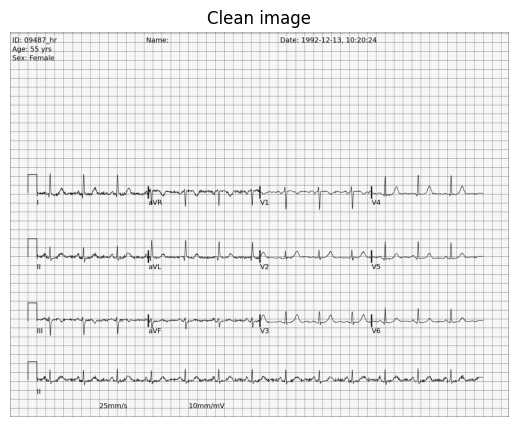

In [3]:
clean_img, clean_path = load_gray_image(selected_ecg_id, clean_scan)

print("ECG ID:", selected_ecg_id)
print("Clean path:", clean_path)
print("Shape:", clean_img.shape)

plt.figure(figsize=(12, 5))
plt.imshow(clean_img, cmap="gray")
plt.title("Clean image")
plt.axis("off")
plt.show()


## Step 2 - Add synthetic ink

We keep the same synthetic setup as in the other notebooks.


Random seed: 19
MAE before on all pixels : 0.015498
MAE before on ink mask   : 0.169262
MAE before outside mask  : 0.000288


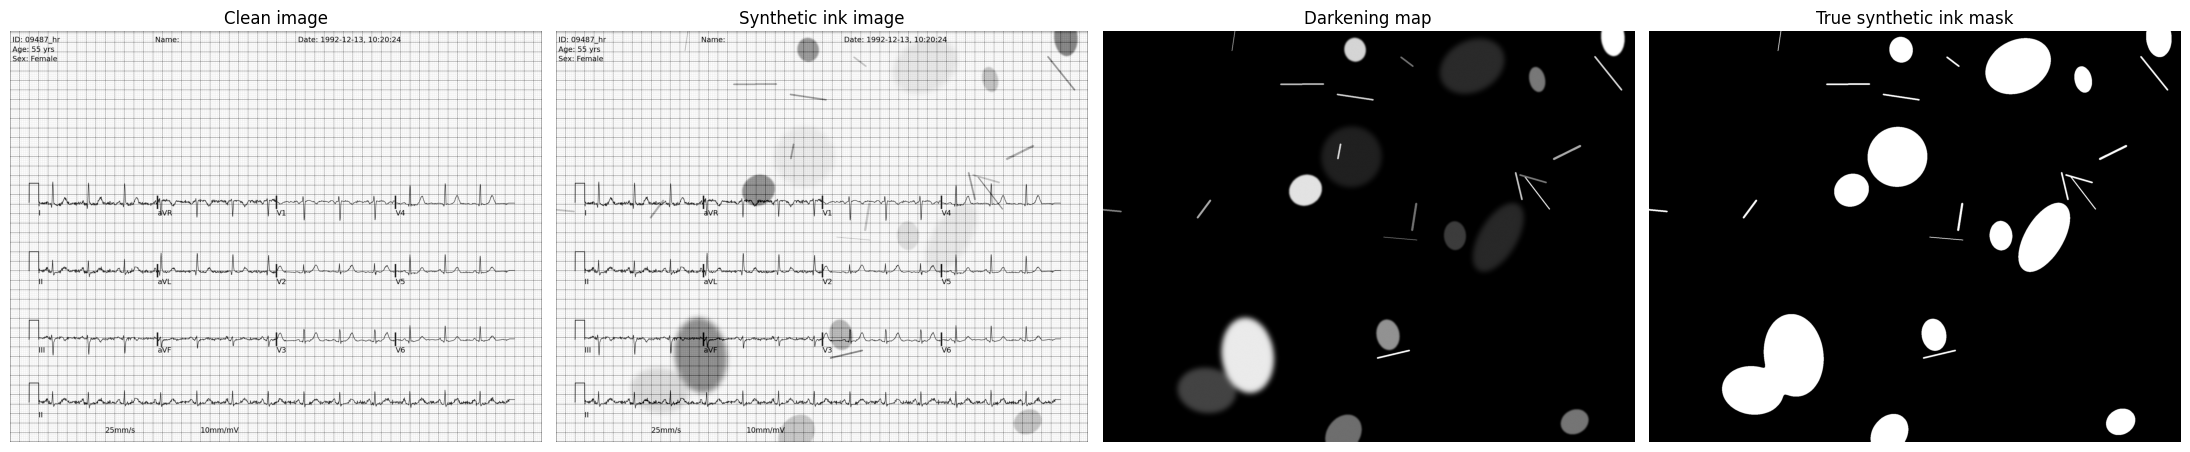

In [4]:
synthetic_ink, darkening_map, true_ink_mask = generate_random_ink_from_clean(
    clean_img,
    seed=RANDOM_SEED,
    n_strokes=N_STROKES,
    n_blobs=N_BLOBS,
    n_smudges=N_SMUDGES,
)

baseline_metrics = collect_metrics("synthetic_ink", synthetic_ink, clean_img, true_ink_mask)

print("Random seed:", RANDOM_SEED)
print(f"MAE before on all pixels : {baseline_metrics['all']:.6f}")
print(f"MAE before on ink mask   : {baseline_metrics['ink']:.6f}")
print(f"MAE before outside mask  : {baseline_metrics['outside']:.6f}")

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(clean_img, cmap="gray")
axes[0].set_title("Clean image")
axes[0].axis("off")
axes[1].imshow(synthetic_ink, cmap="gray")
axes[1].set_title("Synthetic ink image")
axes[1].axis("off")
axes[2].imshow(darkening_map, cmap="gray")
axes[2].set_title("Darkening map")
axes[2].axis("off")
axes[3].imshow(true_ink_mask, cmap="gray")
axes[3].set_title("True synthetic ink mask")
axes[3].axis("off")
plt.tight_layout()
plt.show()


## Step 3 - Reference black-hat only

This is the reference result we want to compare against.


Black-hat kernel: 25
MAE blackhat only on all pixels : 0.001423
MAE blackhat only on ink mask   : 0.015399
MAE blackhat only outside mask  : 0.000041


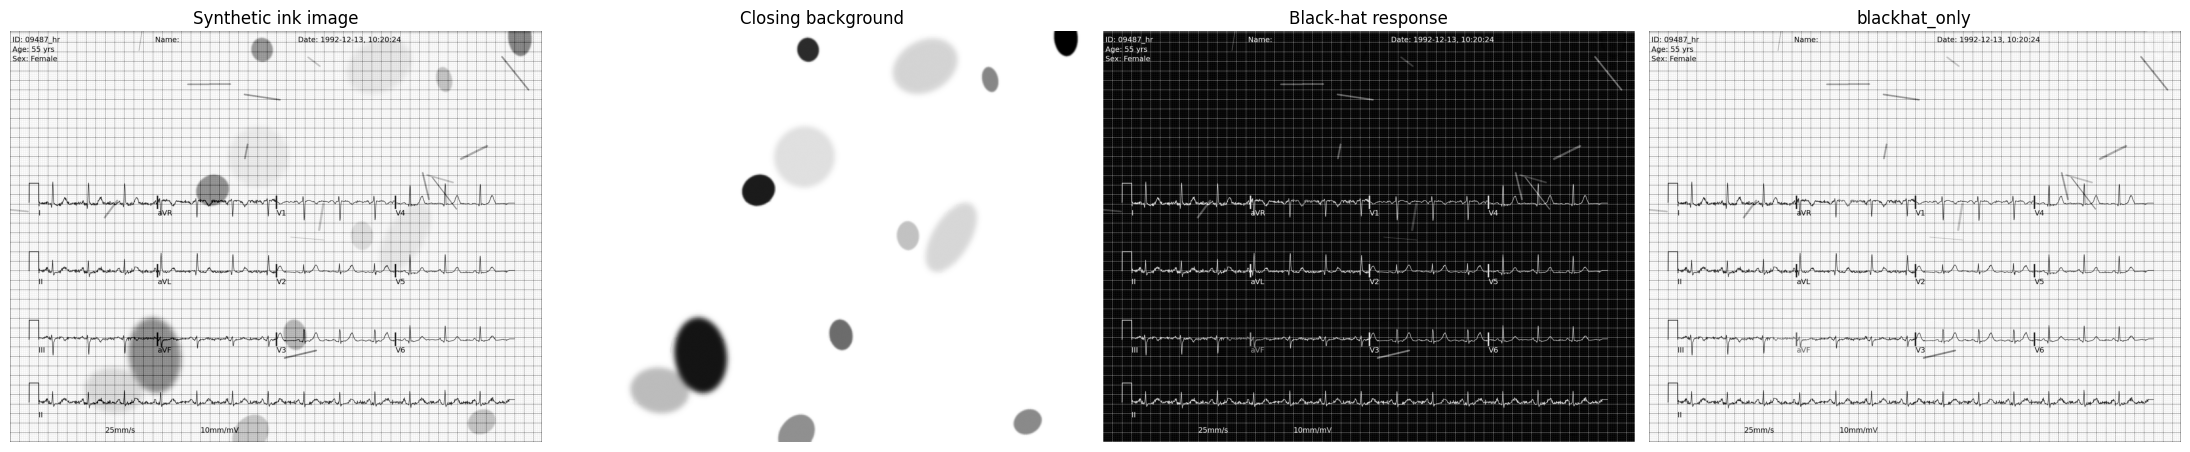

In [5]:
blackhat_only, background_full, blackhat_response = build_blackhat_only(
    synthetic_ink,
    odd_kernel_size(CLOSING_KERNEL),
)
blackhat_only_metrics = collect_metrics("blackhat_only", blackhat_only, clean_img, true_ink_mask)

print("Black-hat kernel:", odd_kernel_size(CLOSING_KERNEL))
print(f"MAE blackhat only on all pixels : {blackhat_only_metrics['all']:.6f}")
print(f"MAE blackhat only on ink mask   : {blackhat_only_metrics['ink']:.6f}")
print(f"MAE blackhat only outside mask  : {blackhat_only_metrics['outside']:.6f}")

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(synthetic_ink, cmap="gray")
axes[0].set_title("Synthetic ink image")
axes[0].axis("off")
axes[1].imshow(background_full, cmap="gray")
axes[1].set_title("Closing background")
axes[1].axis("off")
axes[2].imshow(blackhat_response, cmap="gray")
axes[2].set_title("Black-hat response")
axes[2].axis("off")
axes[3].imshow(blackhat_only, cmap="gray")
axes[3].set_title("blackhat_only")
axes[3].axis("off")
plt.tight_layout()
plt.show()


## Step 4 - Decompose the synthetic image

We split the synthetic image into:
- a Sobel-based derivative part,
- a remaining residual part.

So here:
`synthetic = derivative_component + residual_component`


Derivative weight: 0.2
Max decomposition error: 0.00000006


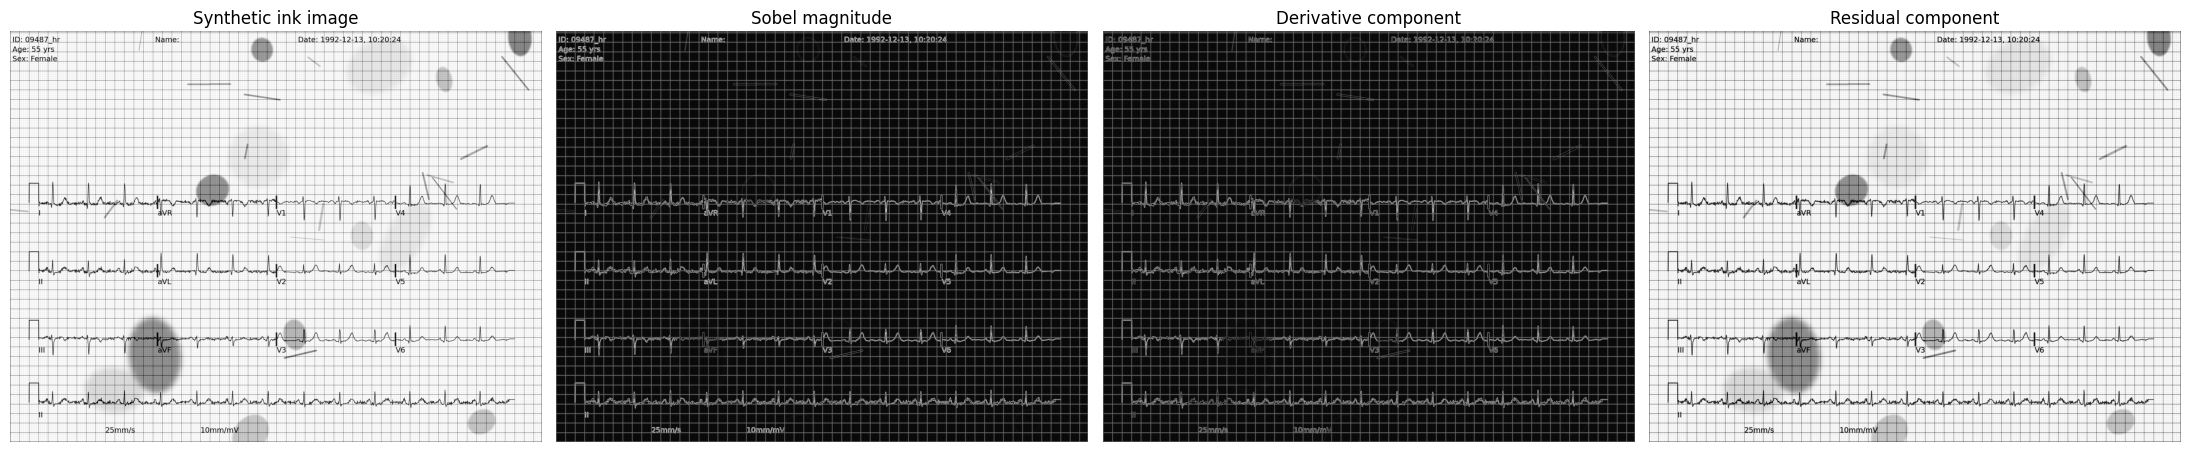

In [6]:
derivative_component, residual_component, sobel_magnitude = build_sobel_derivative_component(
    synthetic_ink,
    DERIVATIVE_WEIGHT,
)
reconstruction_error = np.max(np.abs(synthetic_ink - (derivative_component + residual_component)))

print("Derivative weight:", DERIVATIVE_WEIGHT)
print("Max decomposition error:", f"{reconstruction_error:.8f}")

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(synthetic_ink, cmap="gray")
axes[0].set_title("Synthetic ink image")
axes[0].axis("off")
axes[1].imshow(normalize_for_display(sobel_magnitude), cmap="gray")
axes[1].set_title("Sobel magnitude")
axes[1].axis("off")
axes[2].imshow(derivative_component, cmap="gray")
axes[2].set_title("Derivative component")
axes[2].axis("off")
axes[3].imshow(residual_component, cmap="gray")
axes[3].set_title("Residual component")
axes[3].axis("off")
plt.tight_layout()
plt.show()


## Step 5 - Apply black-hat to the residual and reconstruct

Now we apply black-hat only to the residual part.
Then we add the derivative part back.


MAE final image on all pixels : 0.002214
MAE final image on ink mask   : 0.016986
MAE final image outside mask  : 0.000752


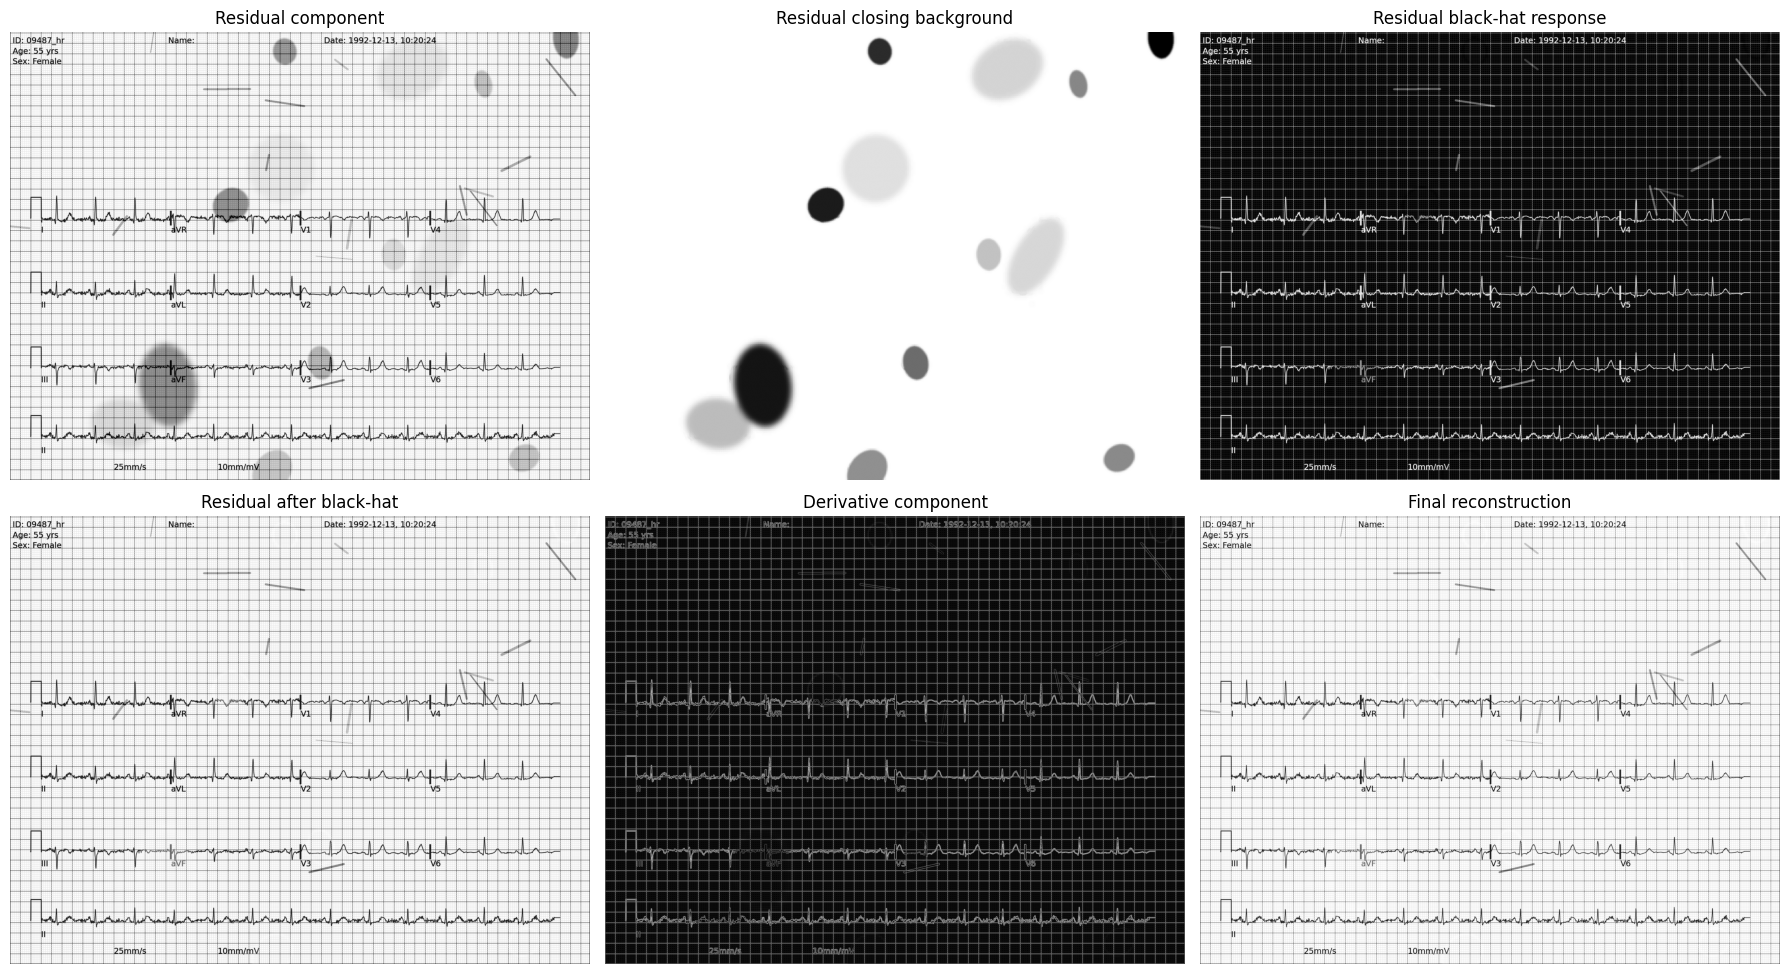

In [7]:
residual_blackhat, residual_background, residual_blackhat_response = build_blackhat_only(
    residual_component,
    odd_kernel_size(CLOSING_KERNEL),
)
final_reconstruction = np.clip(residual_blackhat + derivative_component, 0.0, 1.0)

residual_blackhat_metrics = collect_metrics(
    "residual_blackhat",
    residual_blackhat,
    clean_img,
    true_ink_mask,
)
final_reconstruction_metrics = collect_metrics(
    "final_reconstruction",
    final_reconstruction,
    clean_img,
    true_ink_mask,
)

print(f"MAE final image on all pixels : {final_reconstruction_metrics['all']:.6f}")
print(f"MAE final image on ink mask   : {final_reconstruction_metrics['ink']:.6f}")
print(f"MAE final image outside mask  : {final_reconstruction_metrics['outside']:.6f}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].imshow(residual_component, cmap="gray")
axes[0, 0].set_title("Residual component")
axes[0, 0].axis("off")
axes[0, 1].imshow(residual_background, cmap="gray")
axes[0, 1].set_title("Residual closing background")
axes[0, 1].axis("off")
axes[0, 2].imshow(residual_blackhat_response, cmap="gray")
axes[0, 2].set_title("Residual black-hat response")
axes[0, 2].axis("off")
axes[1, 0].imshow(residual_blackhat, cmap="gray")
axes[1, 0].set_title("Residual after black-hat")
axes[1, 0].axis("off")
axes[1, 1].imshow(derivative_component, cmap="gray")
axes[1, 1].set_title("Derivative component")
axes[1, 1].axis("off")
axes[1, 2].imshow(final_reconstruction, cmap="gray")
axes[1, 2].set_title("Final reconstruction")
axes[1, 2].axis("off")
plt.tight_layout()
plt.show()


## Step 6 - Final comparison table

Now we compare:
- the synthetic image,
- black-hat only,
- the final reconstructed image.


synthetic_ink
  MAE on all pixels : 0.015498
  MAE on ink mask   : 0.169262
  MAE outside mask  : 0.000288
blackhat_only
  MAE on all pixels : 0.001423
  MAE on ink mask   : 0.015399
  MAE outside mask  : 0.000041
final_reconstruction
  MAE on all pixels : 0.002214
  MAE on ink mask   : 0.016986
  MAE outside mask  : 0.000752


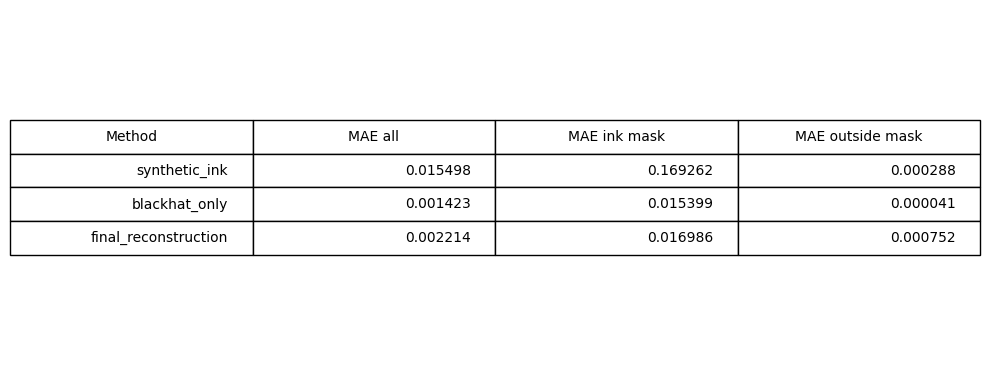

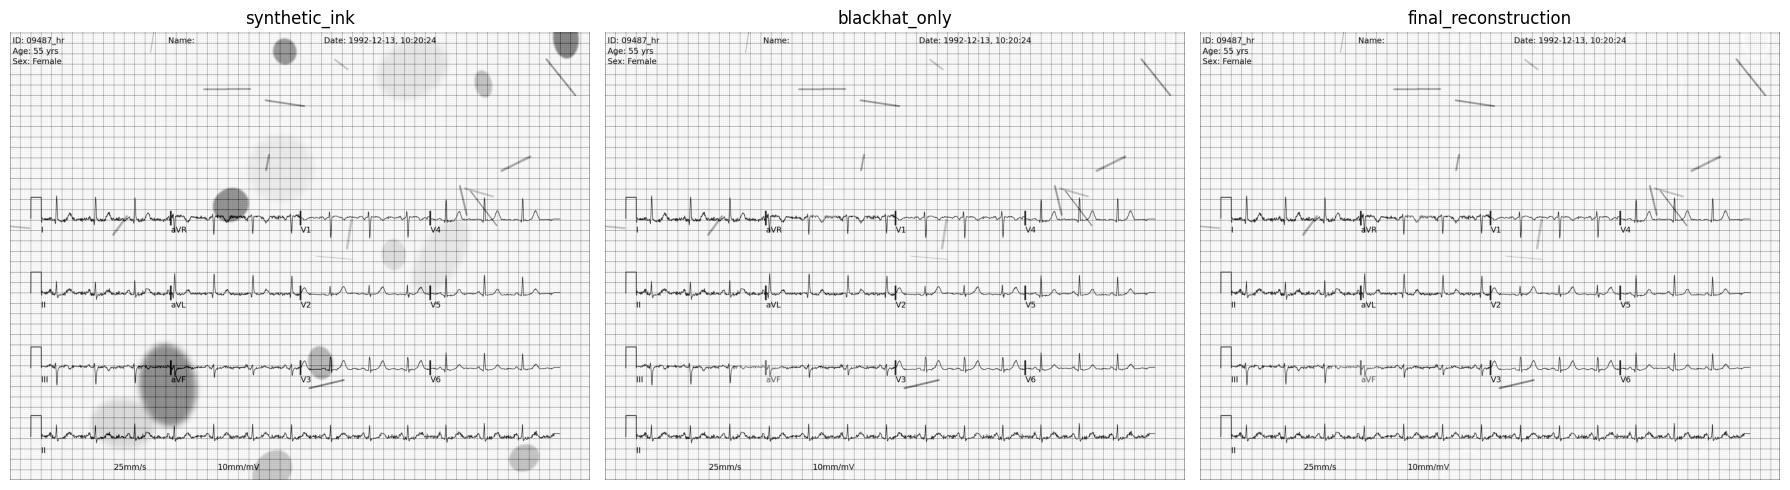

In [8]:
rows = [
    baseline_metrics,
    blackhat_only_metrics,
    final_reconstruction_metrics,
]

for row in rows:
    print(row['method'])
    print("  MAE on all pixels :", f"{row['all']:.6f}")
    print("  MAE on ink mask   :", f"{row['ink']:.6f}")
    print("  MAE outside mask  :", f"{row['outside']:.6f}")

draw_results_table(rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(synthetic_ink, cmap="gray")
axes[0].set_title("synthetic_ink")
axes[0].axis("off")
axes[1].imshow(blackhat_only, cmap="gray")
axes[1].set_title("blackhat_only")
axes[1].axis("off")
axes[2].imshow(final_reconstruction, cmap="gray")
axes[2].set_title("final_reconstruction")
axes[2].axis("off")
plt.tight_layout()
plt.show()


## Conclusion

Saved result on `11842146`:
- `blackhat_only` is best: all-pixel MAE `0.001423`, ink-mask MAE `0.015399`, outside-mask MAE `0.000041`.
- `final_reconstruction` is worse: all-pixel MAE `0.002214`, ink-mask MAE `0.016986`, outside-mask MAE `0.000752`.

So this Sobel-based decomposition does **not** improve the black-hat result.
Adding the derivative component back reintroduces error, especially outside the ink mask.
For this synthetic case, direct black-hat should stay the preferred method.
